# Análisis de Sincronización: Hilbert + Kuramoto + Joint Recurrence Plots (Belousov-Zhabotinsky Delayed) - Output

Resultados del análisis de sincronización entre una serie temporal de BZ y su versión retrasada.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Load saved results
results_df = pd.read_parquet('../data/kuramoto_jrp_lag_sweep_bz_delayed.parquet')
print(f'Loaded {len(results_df)} lag points')
print(results_df.head())

# Real lag definition
real_lag = 1.0  # seconds (100 steps at 100 Hz)

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loaded 141 lag points
   lag  lag_sec    r_mean     r_std  frac_above_07  max_sustained_sec  \
0  -70    -0.70  0.544510  0.188276       0.222615               0.53   
1  -69    -0.69  0.563511  0.184792       0.247077               0.52   
2  -68    -0.68  0.582692  0.179639       0.274308               0.53   
3  -67    -0.67  0.601279  0.176237       0.305692               0.53   
4  -66    -0.66  0.619373  0.171966       0.336154               0.53   

     jrp_RR   jrp_DET   jrp_LAM  jrp_max_diag  kuramoto_score  jrp_score  \
0  0.017486  0.890862  0.882224          6498        0.094215        0.0   
1  0.000000  0.000000  0.000000             0        0.110948        0.0   
2  0.000000  0.000000  0.000000             0        0.130323        0.0   
3  0.000000  0.000000  0.000000             0        0.152987        0.0   
4  0.000000  0.000000  0.000000             0        0.176468        0.0   

   combined_score  
0        0.047108  
1        0.055474  
2        0.065162  
3 

In [2]:
# Summary statistics
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_sec']
best_kuramoto_frac = results_df.loc[results_df['kuramoto_score'].idxmax(), 'frac_above_07']
best_kuramoto_r = results_df.loc[results_df['kuramoto_score'].idxmax(), 'r_mean']

true_delay = 100  # steps
true_delay_sec = true_delay / 100.0  # 1 second at 100 Hz

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()
best_jrp = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 'N/A'
best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])

print('=== FINAL SUMMARY ===')
print(f'True delay:                                         {true_delay} steps ({true_delay_sec:.2f}s)')
print(f'Best lag (Kuramoto - frac_above_07 x r_mean):     {best_kuramoto} steps ({best_kuramoto/100:.2f}s)  [max_sustained={best_kuramoto_sustained:.0f}s, frac_above_07={best_kuramoto_frac:.3f}, r_mean={best_kuramoto_r:.4f}]')
print(f'Best lag (JRP - DET/LAM/RR, excl. extreme lags): {best_jrp} steps ({best_jrp/100:.2f}s)')
print(f'Best lag (Combined):                               {best_combined} steps ({best_combined/100:.2f}s)')

error_kuramoto = abs(best_kuramoto - true_delay) / 100
error_jrp = abs(best_jrp - true_delay) / 100 if best_jrp != 'N/A' else 'N/A'
error_combined = abs(best_combined - true_delay) / 100
print(f'\nErrors vs true delay:')
print(f'  Kuramoto:  {error_kuramoto:.2f}s')
print(f'  JRP (DET/LAM/RR):       {error_jrp:.2f}s' if error_jrp != 'N/A' else '  JRP (DET/LAM/RR):       N/A')
print(f'  Combined:  {error_combined:.2f}s')

=== FINAL SUMMARY ===
True delay:                                         100 steps (1.00s)
Best lag (Kuramoto - frac_above_07 x r_mean):     -29 steps (-0.29s)  [max_sustained=64s, frac_above_07=0.992, r_mean=0.9834]
Best lag (JRP - DET/LAM/RR, excl. extreme lags): -25 steps (-0.25s)
Best lag (Combined):                               -25 steps (-0.25s)

Errors vs true delay:
  Kuramoto:  1.29s
  JRP (DET/LAM/RR):       1.25s
  Combined:  1.25s


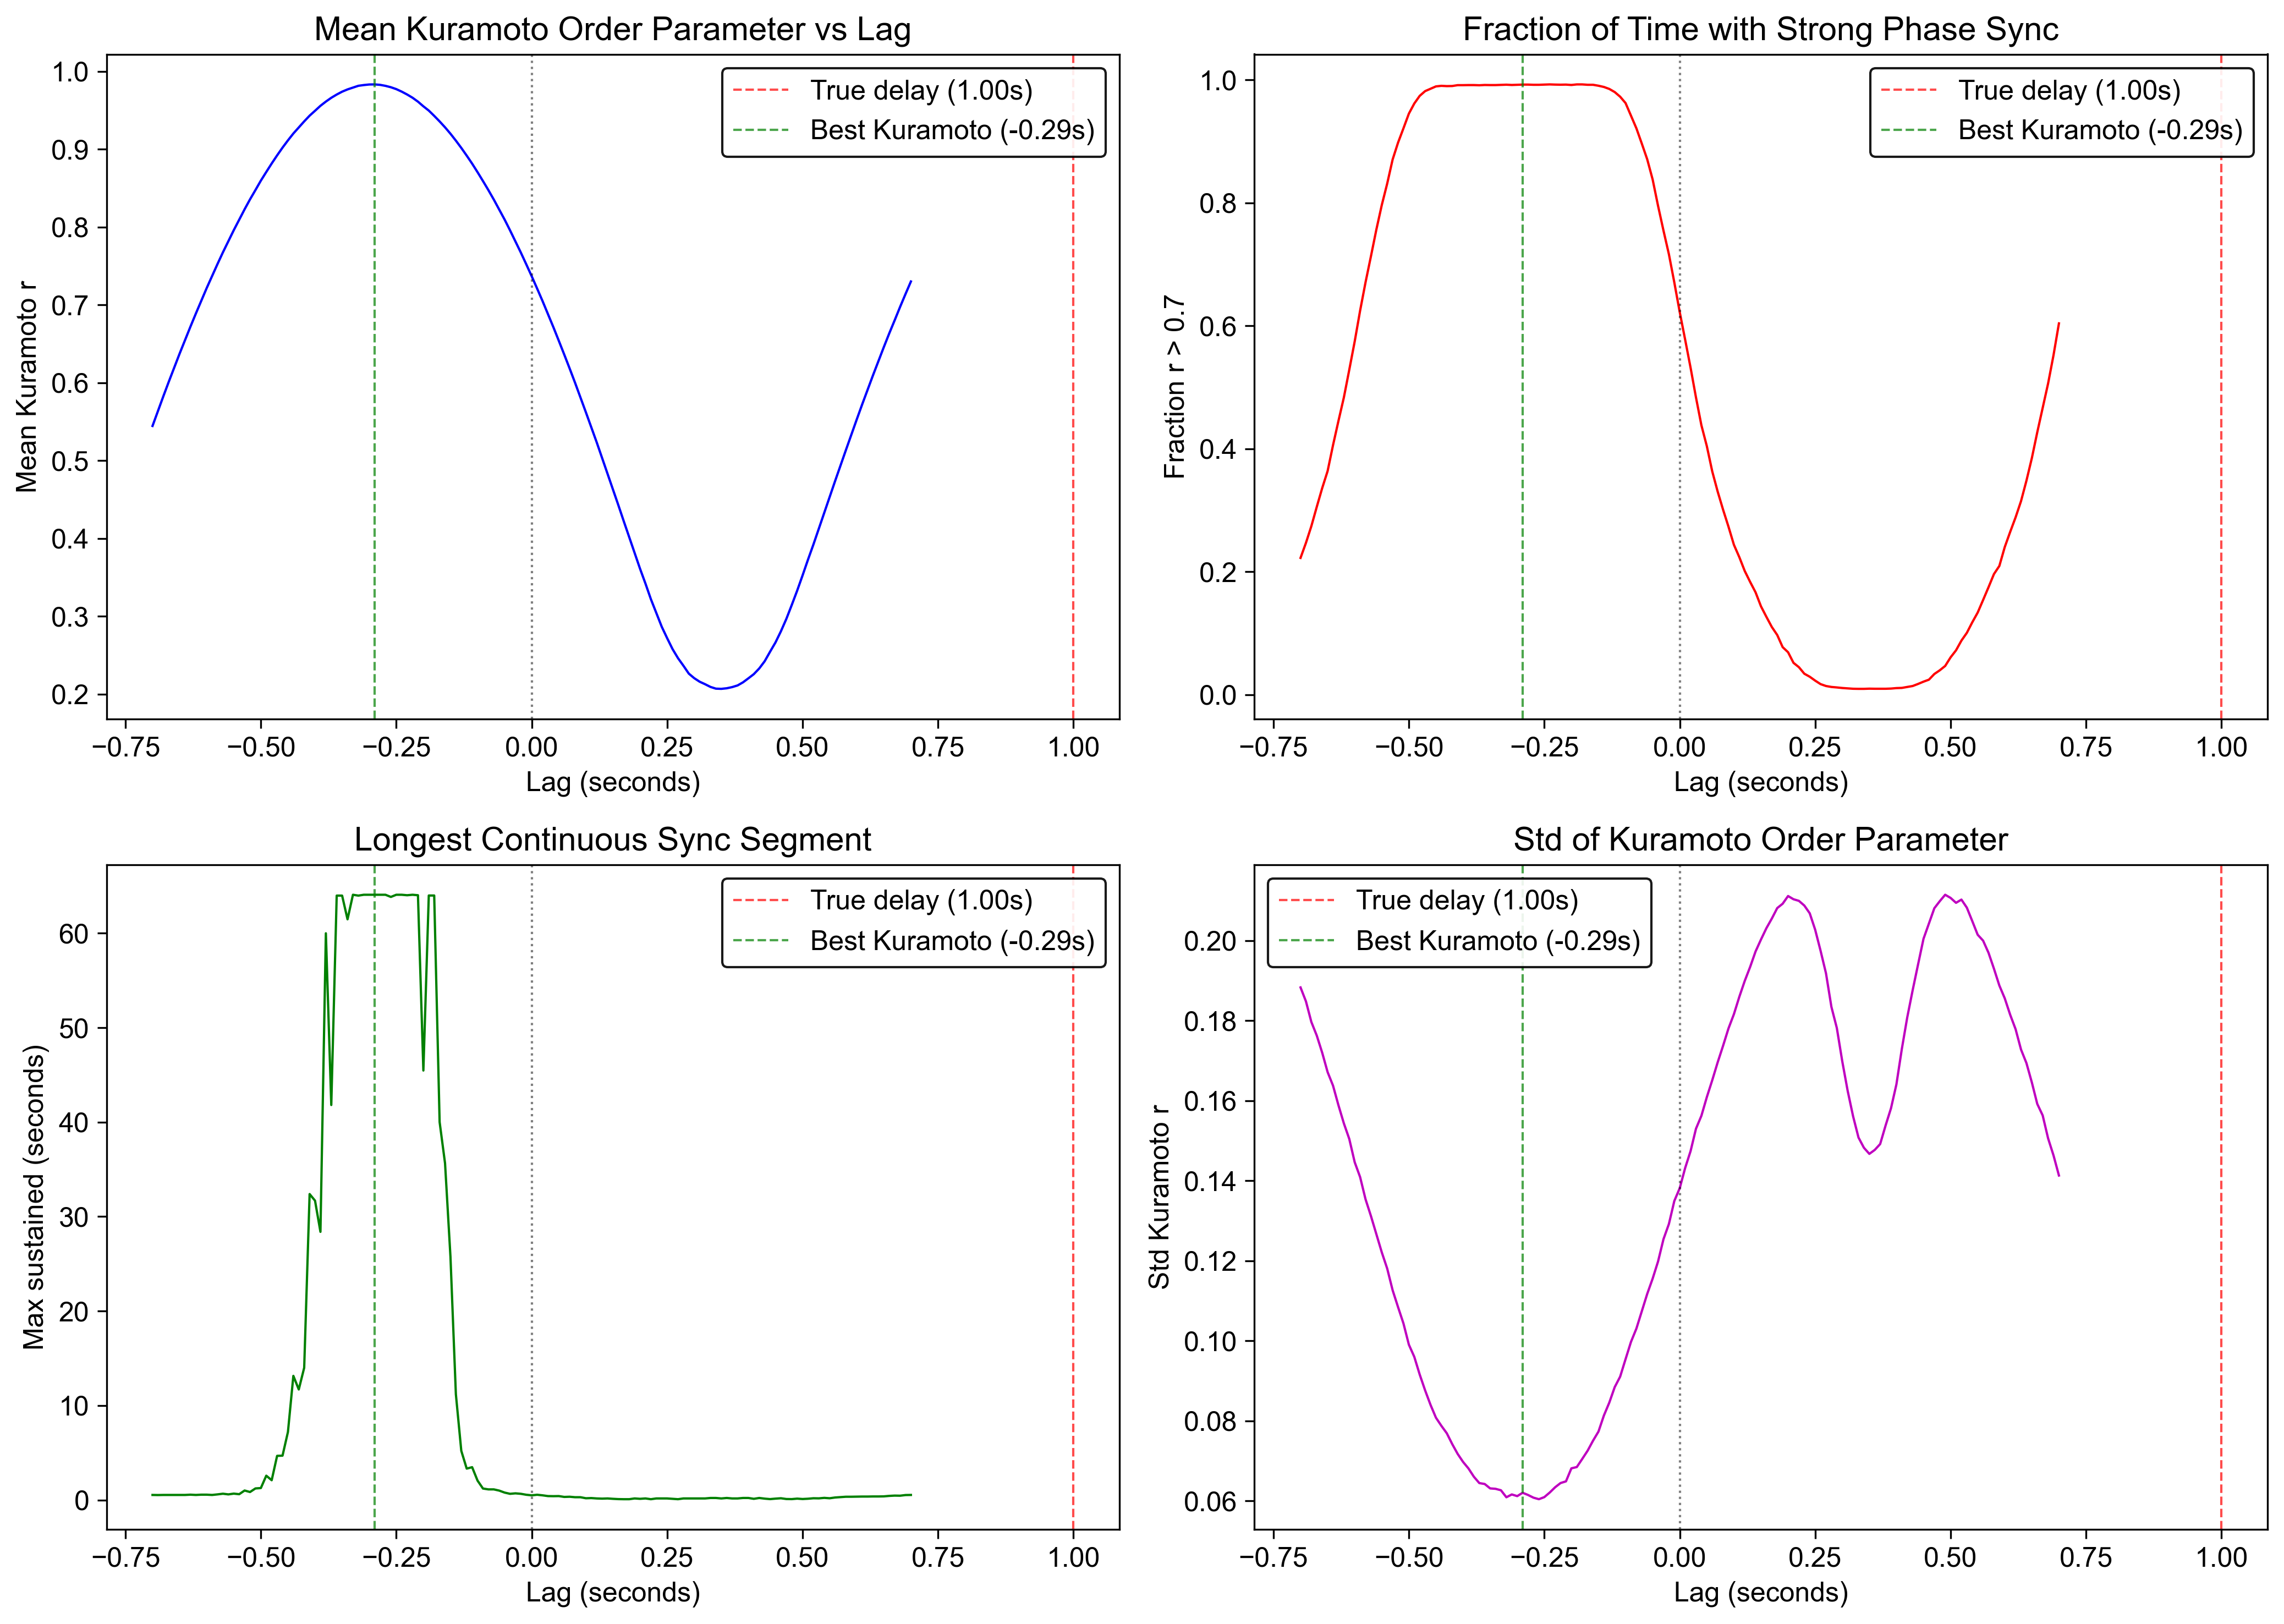

In [3]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(results_df['lag_sec'], results_df['r_mean'], 'b-', linewidth=1)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[0, 0].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(results_df['lag_sec'], results_df['frac_above_07'], 'r-', linewidth=1)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Fraction r > 0.7')
axes[0, 1].set_title('Fraction of Time with Strong Phase Sync')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[0, 1].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(results_df['lag_sec'], results_df['max_sustained_sec'], 'g-', linewidth=1)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Max sustained (seconds)')
axes[1, 0].set_title('Longest Continuous Sync Segment')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[1, 0].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(results_df['lag_sec'], results_df['r_std'], 'm-', linewidth=1)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Std Kuramoto r')
axes[1, 1].set_title('Std of Kuramoto Order Parameter')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[1, 1].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/100:.2f}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

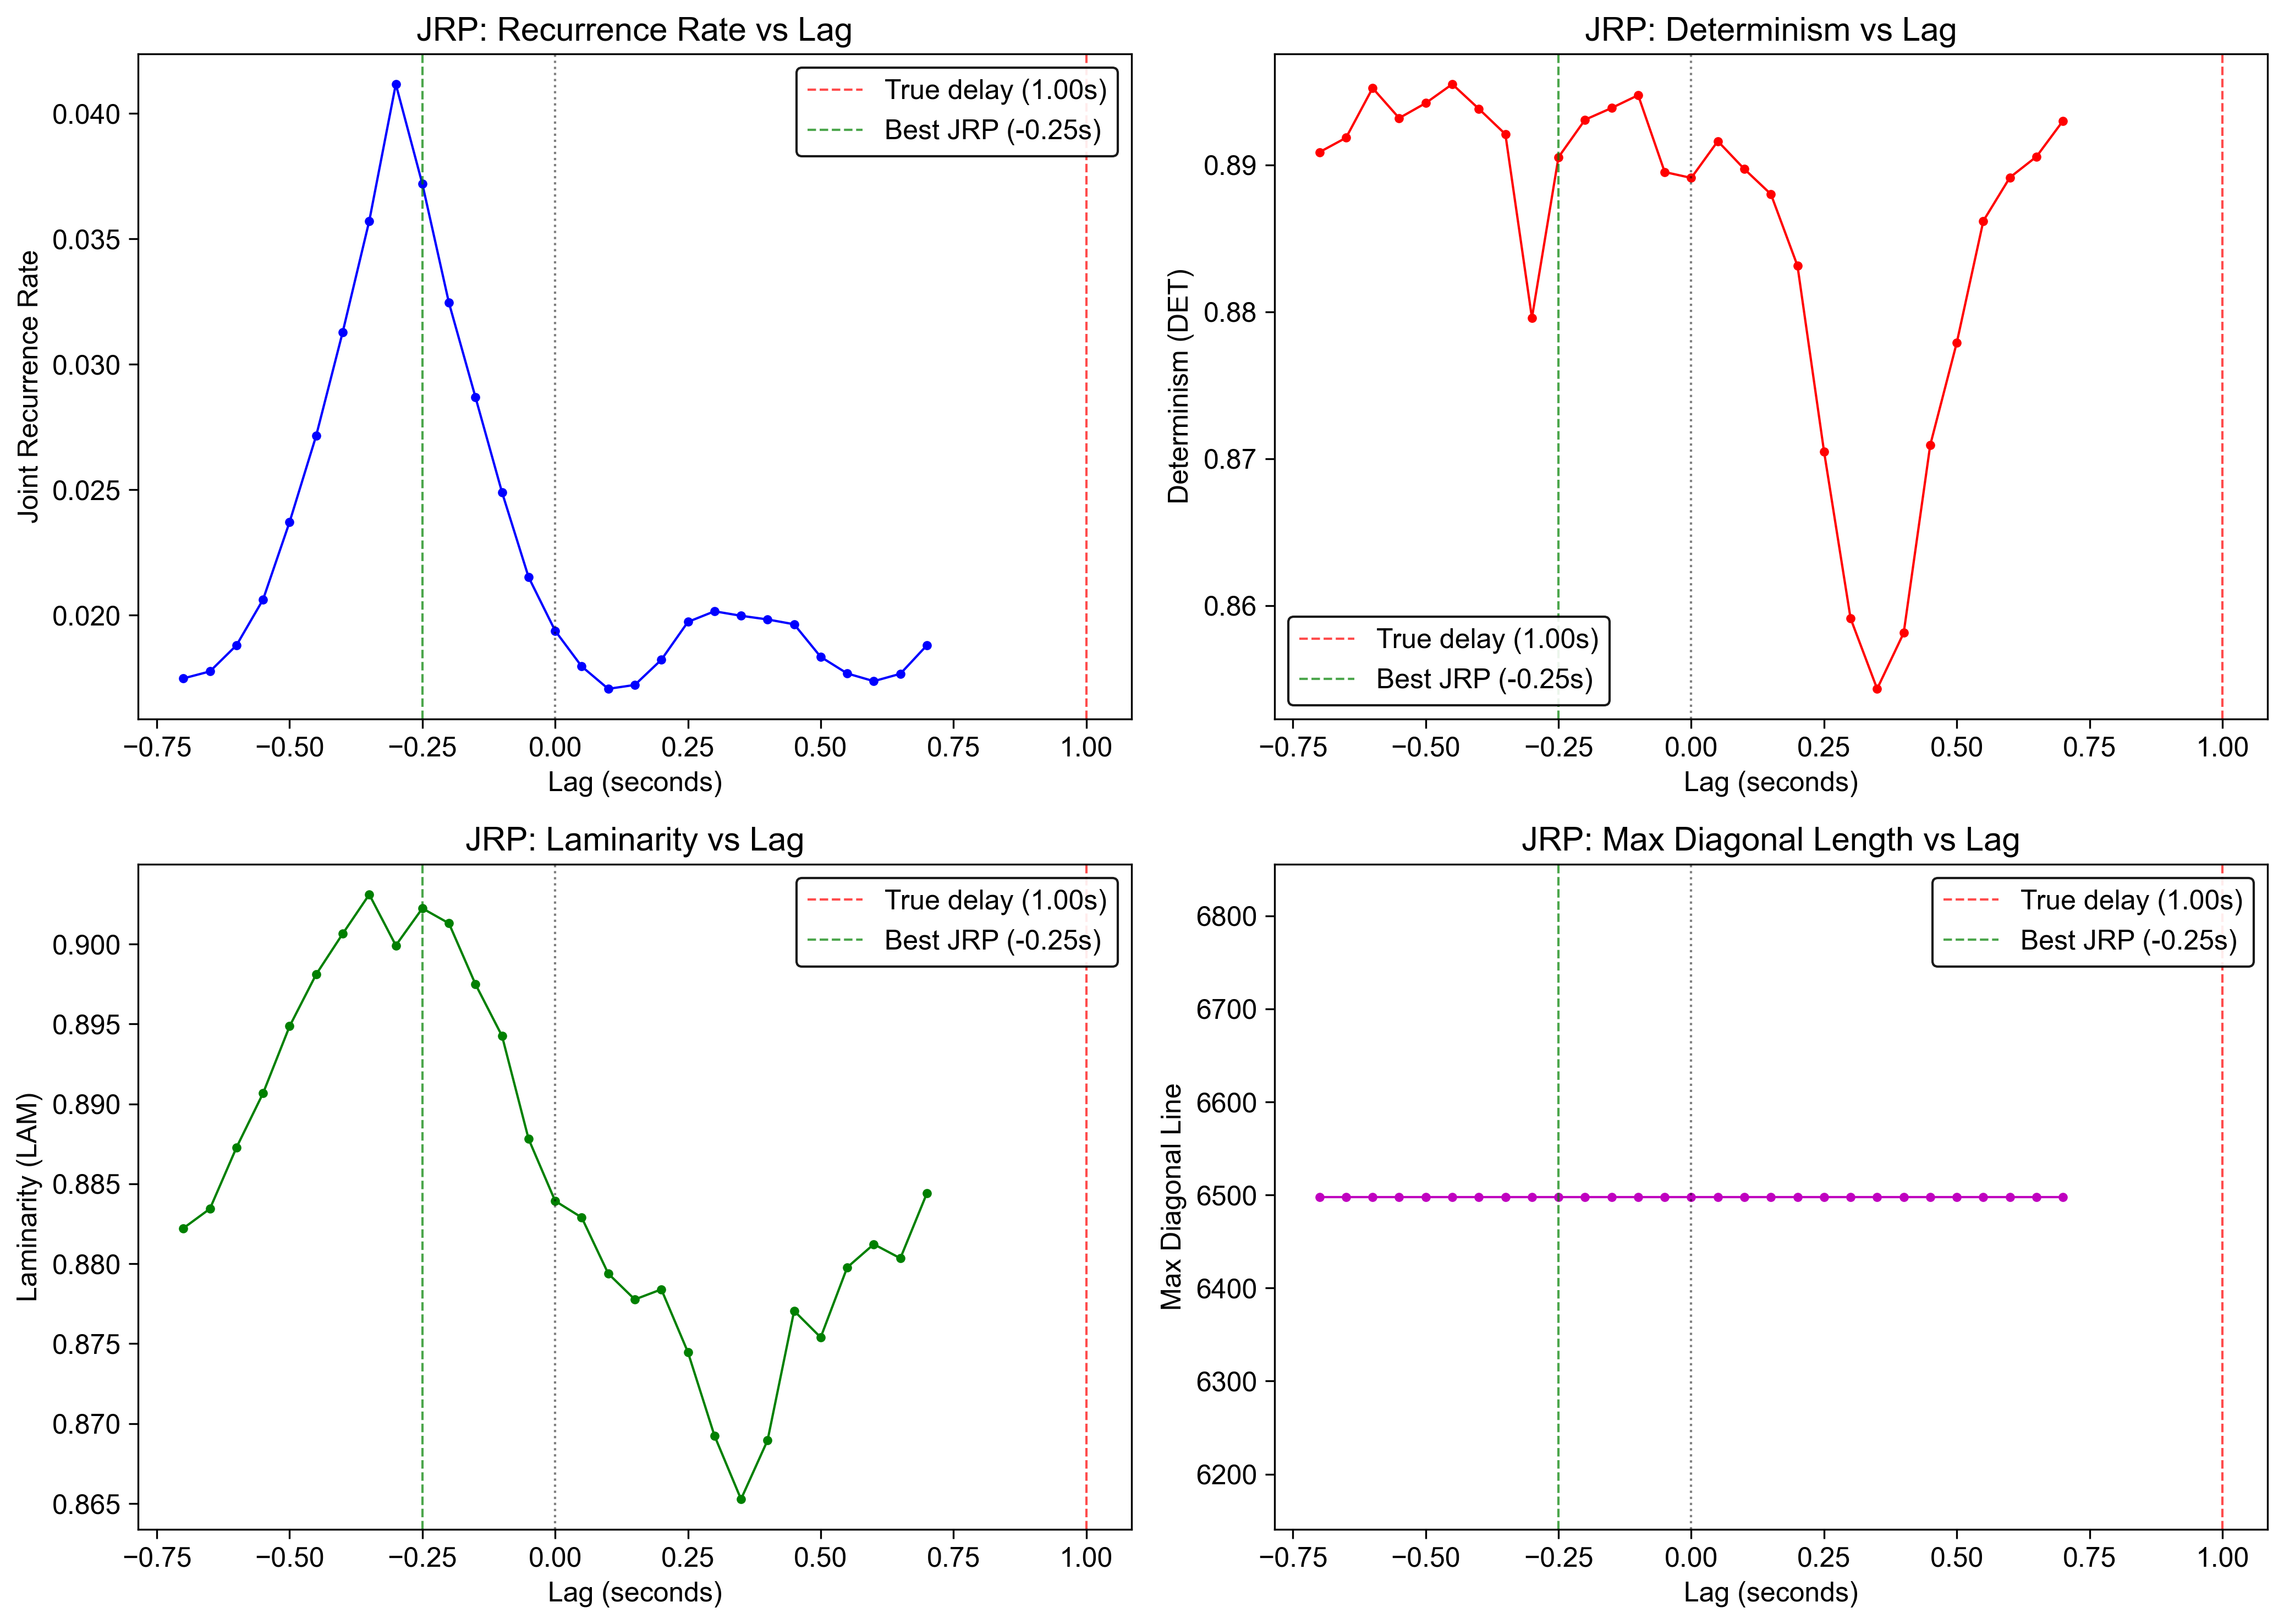

In [4]:
# Plot JRP metrics
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
if best_jrp != 'N/A':
    axes[0, 0].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Determinism (DET)')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
if best_jrp != 'N/A':
    axes[0, 1].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Laminarity (LAM)')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
if best_jrp != 'N/A':
    axes[1, 0].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_max_diag'], 'm-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Max Diagonal Line')
axes[1, 1].set_title('JRP: Max Diagonal Length vs Lag')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
if best_jrp != 'N/A':
    axes[1, 1].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/100:.2f}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

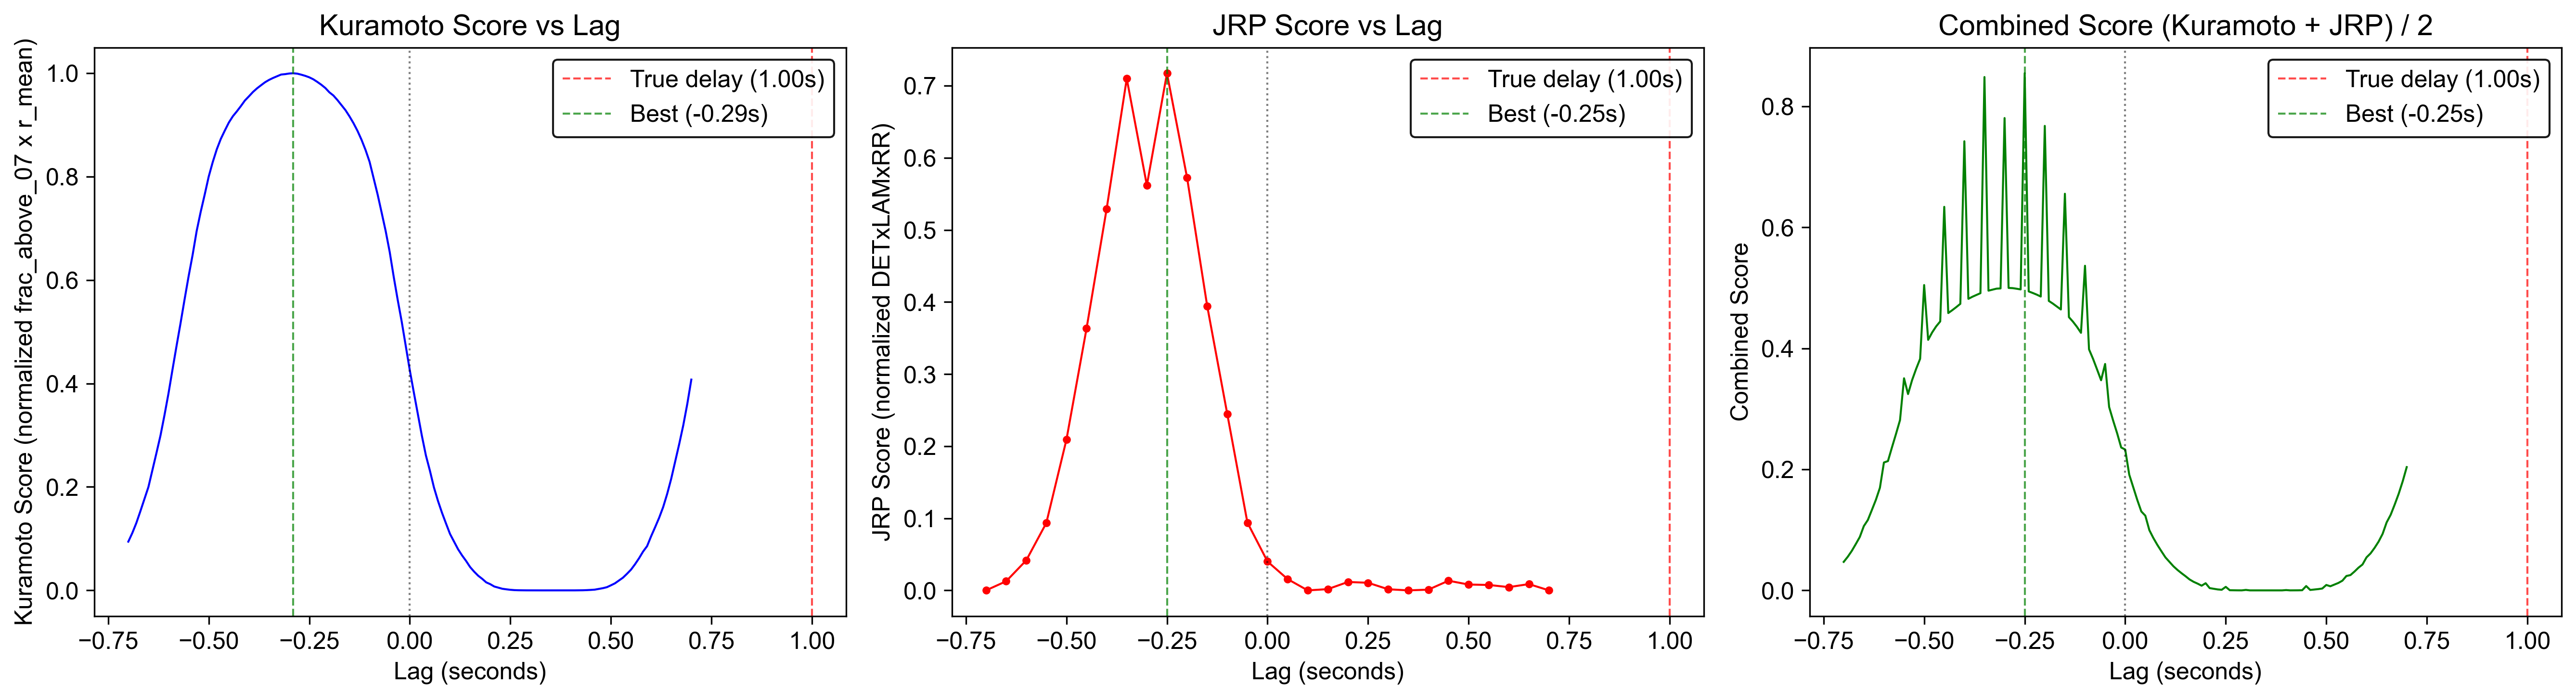

In [5]:
# Combined scores plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

axes[0].plot(results_df['lag_sec'], results_df['kuramoto_score'], 'b-', linewidth=1)
axes[0].set_xlabel('Lag (seconds)')
axes[0].set_ylabel('Kuramoto Score (normalized frac_above_07 x r_mean)')
axes[0].set_title('Kuramoto Score vs Lag')
axes[0].grid(False)
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[0].axvline(x=best_kuramoto/100, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_kuramoto/100:.2f}s)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1].plot(jrp_df['lag_sec'], jrp_df['jrp_score'], 'r-o', linewidth=1, markersize=3)
axes[1].set_xlabel('Lag (seconds)')
axes[1].set_ylabel('JRP Score (normalized DETxLAMxRR)')
axes[1].set_title('JRP Score vs Lag')
axes[1].grid(False)
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
if best_jrp != 'N/A':
    axes[1].axvline(x=best_jrp/100, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_jrp/100:.2f}s)')
axes[1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[2].plot(results_df['lag_sec'], results_df['combined_score'], 'g-', linewidth=1)
axes[2].set_xlabel('Lag (seconds)')
axes[2].set_ylabel('Combined Score')
axes[2].set_title('Combined Score (Kuramoto + JRP) / 2')
axes[2].grid(False)
axes[2].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[2].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[2].axvline(x=best_combined/100, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_combined/100:.2f}s)')
axes[2].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()
plt.show()

In [6]:
# Top 10 results
print('=== Top 10 by Kuramoto Score (frac_above_07 x r_mean) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'kuramoto_score']].to_string(index=False))

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()
print('\n=== Top 10 by JRP Score (excl. extreme lags) ===')
print(jrp_valid.nlargest(10, 'jrp_score')[['lag_sec', 'jrp_RR', 'jrp_DET', 'jrp_LAM', 'jrp_max_diag', 'jrp_score']].to_string(index=False))

print('\n=== Top 10 by Combined Score ===')
print(results_df.nlargest(10, 'combined_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'jrp_RR', 'jrp_DET', 'combined_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (frac_above_07 x r_mean) ===
 lag_sec   r_mean  frac_above_07  max_sustained_sec  kuramoto_score
   -0.29 0.983390       0.992308              64.08        0.999687
   -0.30 0.983287       0.992000              64.08        0.999241
   -0.28 0.982842       0.992308              64.08        0.998982
   -0.31 0.982565       0.991692              64.08        0.997999
   -0.32 0.981613       0.992154              63.99        0.997244
   -0.27 0.981544       0.992000              64.08        0.996998
   -0.26 0.979758       0.992000              63.85        0.994701
   -0.33 0.979297       0.991846              64.08        0.993952
   -0.25 0.977333       0.992308              64.08        0.991891
   -0.34 0.976968       0.991538              61.48        0.990645

=== Top 10 by JRP Score (excl. extreme lags) ===
 lag_sec   jrp_RR  jrp_DET  jrp_LAM  jrp_max_diag  jrp_score
   -0.25 0.037190 0.890519 0.902236          6498   0.717192
   -0.35 0.035718 0.89